# Project title: Assessing the Impact of Serve Performance on Match Advantage in Men’s Tennis via Regression Models

In [1]:
import pandas as pd
import numpy as np
import os


data_path = '/kaggle/input/ml-dataset/dataset_tennis' 

all_files = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.startswith('atp_matches_') and f.endswith('.csv')]

# Leggi e concatena tutti i file
df_list = [pd.read_csv(file) for file in all_files]
df = pd.concat(df_list, ignore_index=True)

print(df.shape)
display(df.head())

(74906, 49)


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2013-339,Brisbane,Hard,28,A,20121230,1,105357,NaN,Q,...,26.0,19.0,8.0,8.0,3.0,7.0,199.0,239.0,79.0,655.0
1,2013-339,Brisbane,Hard,28,A,20121230,2,103720,NaN,WC,...,53.0,37.0,19.0,14.0,6.0,10.0,83.0,625.0,162.0,339.0
2,2013-339,Brisbane,Hard,28,A,20121230,3,104797,NaN,NaN,...,31.0,19.0,9.0,7.0,9.0,13.0,43.0,897.0,30.0,1175.0
3,2013-339,Brisbane,Hard,28,A,20121230,4,103813,NaN,NaN,...,48.0,29.0,7.0,12.0,1.0,6.0,41.0,927.0,35.0,1075.0
4,2013-339,Brisbane,Hard,28,A,20121230,5,103990,NaN,NaN,...,39.0,26.0,20.0,11.0,0.0,1.0,114.0,495.0,69.0,710.0


# Dataset analysis

In [2]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74906 entries, 0 to 74905
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          74906 non-null  object 
 1   tourney_name        74906 non-null  object 
 2   surface             74853 non-null  object 
 3   draw_size           74906 non-null  int64  
 4   tourney_level       74906 non-null  object 
 5   tourney_date        74906 non-null  int64  
 6   match_num           74906 non-null  int64  
 7   winner_id           74906 non-null  int64  
 8   winner_seed         31120 non-null  float64
 9   winner_entry        9506 non-null   object 
 10  winner_name         74906 non-null  object 
 11  winner_hand         74906 non-null  object 
 12  winner_ht           73481 non-null  float64
 13  winner_ioc          74906 non-null  object 
 14  winner_age          74901 non-null  float64
 15  loser_id            74906 non-null  int64  
 16  lose

In [3]:
df.describe()

,draw_size,tourney_date,match_num,winner_id,winner_seed,winner_ht,winner_age,loser_id,loser_seed,loser_ht,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
count,74906.000000,7.490600e+04,74906.000000,74906.000000,31120.000000,73481.000000,74901.000000,74906.000000,17238.000000,71997.000000,...,68386.000000,68386.000000,68386.000000,68386.000000,68386.000000,68386.000000,74333.000000,74333.000000,73438.000000,73438.000000
mean,55.345126,2.011551e+07,102.269164,111056.333818,7.402635,186.273363,26.289788,111055.887299,8.920931,185.671570,...,48.635481,32.474790,14.929576,12.308104,4.771898,8.601468,79.644250,1608.435755,117.699965,977.409039
std,40.315190,7.240072e+04,133.184752,22766.835939,6.815177,7.028887,3.980862,22671.363557,7.366649,6.979333,...,19.198909,14.358641,7.185611,4.220819,3.271866,4.145550,138.795266,2006.339266,185.938285,1125.591169
min,2.000000,2.000010e+07,1.000000,100644.000000,1.000000,3.000000,14.900000,100644.000000,1.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,32.000000,2.005080e+07,12.000000,103565.000000,3.000000,183.000000,23.400000,103490.000000,4.000000,181.000000,...,35.000000,22.000000,10.000000,9.000000,2.000000,6.000000,18.000000,577.000000,36.000000,430.000000
50%,32.000000,2.011072e+07,30.000000,104494.000000,5.000000,185.000000,26.100000,104471.000000,7.000000,185.000000,...,45.000000,30.000000,14.000000,11.000000,4.000000,8.000000,45.000000,940.000000,68.000000,710.000000
75%,64.000000,2.018012e+07,220.000000,105493.000000,9.000000,190.000000,28.900000,105613.000000,12.000000,190.000000,...,59.000000,40.000000,19.000000,15.000000,7.000000,11.000000,85.000000,1732.000000,114.000000,1105.000000
max,128.000000,2.024122e+07,1701.000000,212721.000000,35.000000,211.000000,44.600000,212970.000000,35.000000,211.000000,...,328.000000,284.000000,101.000000,91.000000,27.000000,38.000000,2101.000000,16950.000000,2159.000000,16950.000000


In [4]:
serve_cols = ['w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
              'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'score']

missing_percentage = df[serve_cols].isnull().sum() / len(df) * 100
print(missing_percentage)

w_ace       8.704243
w_df        8.704243
w_svpt      8.704243
w_1stIn     8.704243
w_1stWon    8.704243
w_2ndWon    8.704243
l_ace       8.704243
l_df        8.704243
l_svpt      8.704243
l_1stIn     8.704243
l_1stWon    8.704243
l_2ndWon    8.704243
score       0.000000
dtype: float64


# Cleaning the dataset

In [5]:
# create a copy
df_clean = df.copy()

# Remove rows with missing service data
df_clean.dropna(subset=serve_cols, inplace=True)

print("Original dimensions:", df.shape)
print("Dimensions after cleaning:", df_clean.shape)


Original dimensions: (74906, 49)
Dimensions after cleaning: (68386, 49)


# Creation of the Target Variable and Exploratory Data Analysis (EDA)

* Target variable that will be represented as the difference of the game


In [6]:
def parse_score(score_str):
    # Check of ritiri, walkover, etc.
    if 'RET' in score_str or 'W/O' in score_str or 'DEF' in score_str:
        return np.nan, np.nan

    winner_games = 0
    loser_games = 0
    sets = score_str.split(' ') # Divide in set "6-4", "7-6(4)"

    for s in sets:
        # Ignora tiebreak in parentesi, se presenti
        s = s.split('(')[0] 
        
        # Prova a splittare per il trattino
        parts = s.split('-')
        if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
            g1 = int(parts[0])
            g2 = int(parts[1])
            
            # Il vincitore del set ha sempre più game (o è un tiebreak)
            winner_games += max(g1, g2)
            loser_games += min(g1, g2)
    
    return winner_games, loser_games

# Applica la funzione al DataFrame
# Nota: df_clean['score'].apply(...) potrebbe essere lento.
# Un'iterazione ottimizzata è meglio, ma per iniziare va bene.
scores = df_clean['score'].apply(parse_score)
df_clean['w_games_won'] = scores.apply(lambda x: x[0])
df_clean['l_games_won'] = scores.apply(lambda x: x[1])

# Rimuovi le righe dove il parsing ha fallito (es. ritiri)
df_clean.dropna(subset=['w_games_won', 'l_games_won'], inplace=True)

## Creation target variable

In [7]:
df_clean['game_diff'] = df_clean['w_games_won'] - df_clean['l_games_won']

## Let's visualize the data

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


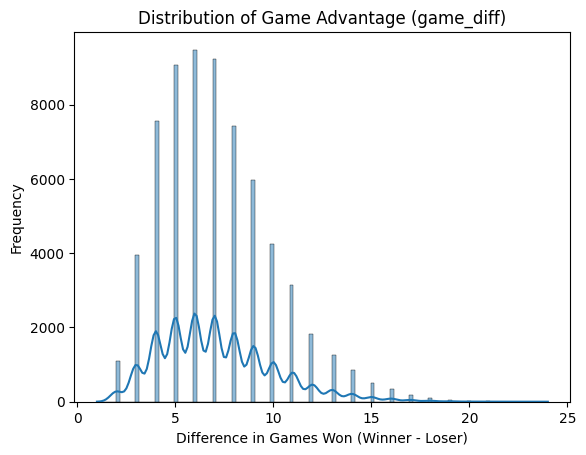

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_clean['game_diff'], kde=True)
plt.title('Distribution of Game Advantage (game_diff)')
plt.xlabel('Difference in Games Won (Winner - Loser)')
plt.ylabel('Frequency')
plt.show()


## Creation of differential variables


In [9]:
import numpy as np

# --- Let's start with the simpler features that do not require divisions ---

# 1. Difference in the number of Aces
# A positive value means the winner made more aces.
df_clean['ace_diff'] = df_clean['w_ace'] - df_clean['l_ace']

# 2. Difference in the number of Double Faults
# We use (loser_df - winner_df) so that a positive value is "good" for the winner (made fewer double faults).
# This helps interpret the coefficients in a linear model.
df_clean['df_diff'] = df_clean['l_df'] - df_clean['w_df']


# --- Now let's move to percentage features, handling divisions by zero ---

# Helper function to safely calculate percentages
def safe_division(numerator, denominator):
    """Performs division, returning 0 if the denominator is 0."""
    # Replaces NaN or Inf with 0 after division.
    # np.divide handles data types and zeros well.
    result = np.divide(numerator, denominator)
    # If denominator was 0, result will be NaN or Inf. Replace those with 0.
    # The logic is that if there was no opportunity (e.g., 0 break points faced),
    # the contribution of that stat is zero, not infinite.
    result[np.isinf(result) | np.isnan(result)] = 0
    return result

# 3. Difference in percentage of 1st Serves In
w_1stIn_pct = safe_division(df_clean['w_1stIn'], df_clean['w_svpt'])
l_1stIn_pct = safe_division(df_clean['l_1stIn'], df_clean['l_svpt'])
df_clean['1st_serve_in_pct_diff'] = w_1stIn_pct - l_1stIn_pct

# 4. Difference in percentage of Points Won on 1st Serve
# This is a key effectiveness metric.
w_1stWon_pct = safe_division(df_clean['w_1stWon'], df_clean['w_1stIn'])
l_1stWon_pct = safe_division(df_clean['l_1stWon'], df_clean['l_1stIn'])
df_clean['1st_serve_win_pct_diff'] = w_1stWon_pct - l_1stWon_pct

# 5. Difference in percentage of Points Won on 2nd Serve
# Calculate total points played on the second serve
w_2nd_sv_pts = df_clean['w_svpt'] - df_clean['w_1stIn']
l_2nd_sv_pts = df_clean['l_svpt'] - df_clean['l_1stIn']
w_2ndWon_pct = safe_division(df_clean['w_2ndWon'], w_2nd_sv_pts)
l_2ndWon_pct = safe_division(df_clean['l_2ndWon'], l_2nd_sv_pts)
df_clean['2nd_serve_win_pct_diff'] = w_2ndWon_pct - l_2ndWon_pct

# 6. Difference in percentage of Break Points Saved
# This metric measures performance "under pressure."
w_bpSaved_pct = safe_division(df_clean['w_bpSaved'], df_clean['w_bpFaced'])
l_bpSaved_pct = safe_division(df_clean['l_bpSaved'], df_clean['l_bpFaced'])
df_clean['bp_saved_pct_diff'] = w_bpSaved_pct - l_bpSaved_pct

# --- Creating the final DataFrame for modeling ---

# List of new differential features we've created
feature_cols = [
    'ace_diff',
    'df_diff',
    '1st_serve_in_pct_diff',
    '1st_serve_win_pct_diff',
    '2nd_serve_win_pct_diff',
    'bp_saved_pct_diff'
]

# Target column
target_col = 'game_diff'

# Create the DataFrame to use for training models.
# Contains only features and target, nothing else.
model_df = df_clean[feature_cols + [target_col]].copy()

# --- Final checks ---
print("First 5 rows of the modeling DataFrame:")
display(model_df.head())

print("\nChecking for null or infinite values in the final DataFrame:")
# Check for any null values
print("Null values:\n", model_df.isnull().sum())
# Check for infinite values
print("\nInfinite values:\n", model_df.isin([np.inf, -np.inf]).sum())


First 5 rows of the modeling DataFrame:


,ace_diff,df_diff,1st_serve_in_pct_diff,1st_serve_win_pct_diff,2nd_serve_win_pct_diff,bp_saved_pct_diff,game_diff
0,5.0,-1.0,0.147115,0.019231,0.143704,0.321429,7.0
1,1.0,3.0,-0.042600,0.154828,0.186957,-0.100000,9.0
2,3.0,1.0,0.078782,0.235582,0.053846,0.307692,9.0
3,-2.0,5.0,-0.015502,0.030754,0.165689,0.560606,12.0
4,2.0,1.0,0.207721,0.193333,-0.118227,1.000000,3.0



Checking for null or infinite values in the final DataFrame:
Null values:
 ace_diff                  0
df_diff                   0
1st_serve_in_pct_diff     0
1st_serve_win_pct_diff    0
2nd_serve_win_pct_diff    0
bp_saved_pct_diff         0
game_diff                 0
dtype: int64

Infinite values:
 ace_diff                  0
df_diff                   0
1st_serve_in_pct_diff     0
1st_serve_win_pct_diff    0
2nd_serve_win_pct_diff    0
bp_saved_pct_diff         0
game_diff                 0
dtype: int64


# Check correlation between data
###  Pearson correlation

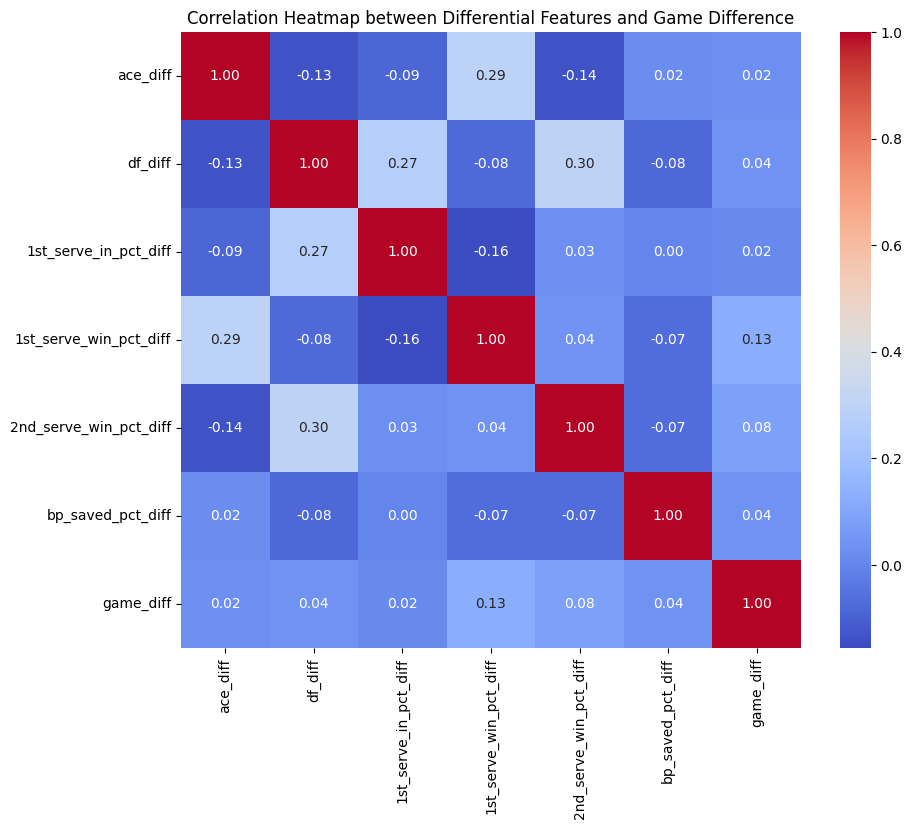

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
correlation_matrix = model_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap between Differential Features and Game Difference')
plt.show()


# Modeling Preparation

* Split train and test

In [11]:
from sklearn.model_selection import train_test_split

# Define X and y
X = model_df[feature_cols]
y = model_df[target_col]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size (X):", X_train.shape)
print("Test set size (X):", X_test.shape)


Training set size (X): (53051, 6)
Test set size (X): (13263, 6)


# Baseline: Linear regression

--- Baseline Results (Linear Regression) ---
Mean Absolute Error (MAE): 2.2585
Root Mean Squared Error (RMSE): 2.8844
R-squared (R²): 0.0274

--- Linear Model Coefficients ---
                  Feature  Coefficient
3  1st_serve_win_pct_diff     0.392051
4  2nd_serve_win_pct_diff     0.202882
5       bp_saved_pct_diff     0.152364
2   1st_serve_in_pct_diff     0.087405
1                 df_diff     0.069331
0                ace_diff    -0.010424


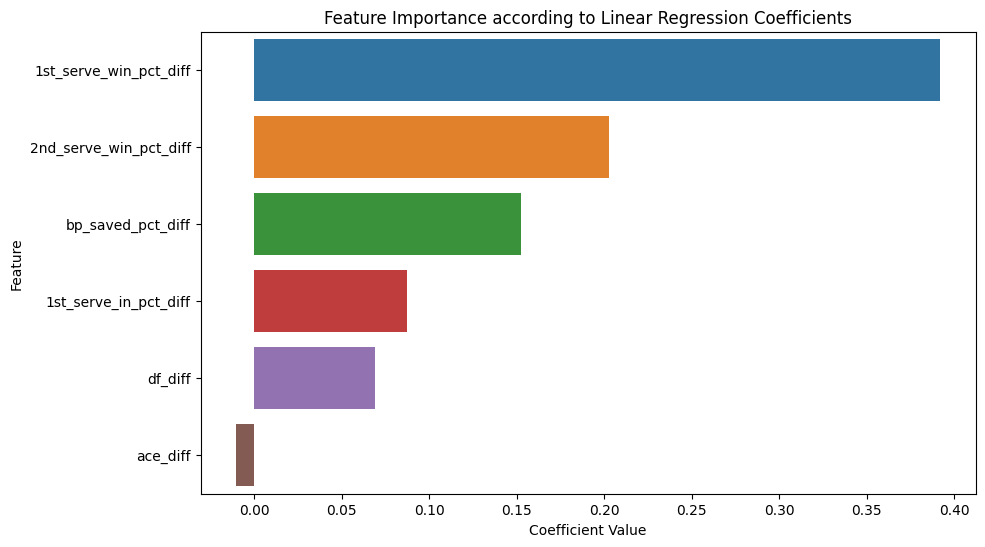

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- 1. Data Standardization ---
# We standardize the features to have mean 0 and standard deviation 1.

# Create the scaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test set using the scaler fitted on the training set
X_test_scaled = scaler.transform(X_test)


# --- 2. Model Training ---
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Train the model on the standardized training data
lr_model.fit(X_train_scaled, y_train)


# --- 3. Make Predictions ---
# Predict on the test set
y_pred_lr = lr_model.predict(X_test_scaled)


# --- 4. Model Evaluation ---
# Calculate performance metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Baseline Results (Linear Regression) ---")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"R-squared (R²): {r2_lr:.4f}")


# --- 5. Interpretability Analysis (Coefficients) ---

# Create a DataFrame to display the coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Linear Model Coefficients ---")
print(coefficients)

# Plotting the coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Feature Importance according to Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()


# Random Forest
Unlike linear models, Random Forest does not assume any predefined relationship between features and the target. It builds hundreds of decision trees on random subsets of the data and features, and then averages their predictions. This makes it very powerful and robust against overfitting.

Starting Random Forest training...
Training completed.

--- Model #3 Results (Random Forest) ---
Mean Absolute Error (MAE): 2.0833
Root Mean Squared Error (RMSE): 2.7310
R-squared (R²): 0.1281

--- Feature Importance according to Random Forest ---
                  Feature  Importance
3  1st_serve_win_pct_diff    0.215221
4  2nd_serve_win_pct_diff    0.207760
5       bp_saved_pct_diff    0.200147
2   1st_serve_in_pct_diff    0.180946
0                ace_diff    0.116731
1                 df_diff    0.079195


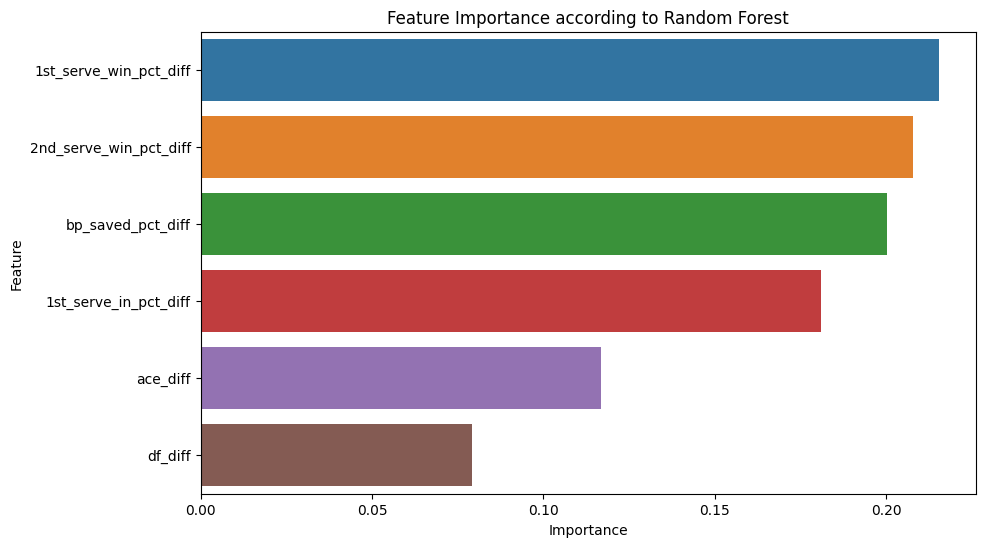

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Training the Random Forest Model ---
# Initialize the model with basic parameters
# n_estimators: number of trees to build.
# random_state=42: for reproducibility.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Starting Random Forest training...")
# Train the model on the training data
rf_model.fit(X_train, y_train)
print("Training completed.")


# --- 2. Making Predictions ---
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)


# --- 3. Model Evaluation ---
# Calculate performance metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Model #3 Results (Random Forest) ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"R-squared (R²): {r2_rf:.4f}")


# --- 4. Interpretability Analysis (Feature Importance) ---

rf_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance according to Random Forest ---")
print(rf_importances)

# Visualizing feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importances)
plt.title('Feature Importance according to Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


# XGBoost Regressor

* GBoost is an optimized and highly efficient implementation of Gradient Boosting.
* It is famous for winning many Kaggle competitions on tabular data and is considered state-of-the-art in many applications.

Starting XGBoost training...
Training completed.

--- Model #4 Results (XGBoost) ---
Mean Absolute Error (MAE): 2.0659
Root Mean Squared Error (RMSE): 2.7039
R-squared (R²): 0.1453

--- Feature Importance according to XGBoost ---
                  Feature  Importance
5       bp_saved_pct_diff    0.303981
3  1st_serve_win_pct_diff    0.209714
4  2nd_serve_win_pct_diff    0.185772
1                 df_diff    0.154447
2   1st_serve_in_pct_diff    0.074030
0                ace_diff    0.072055


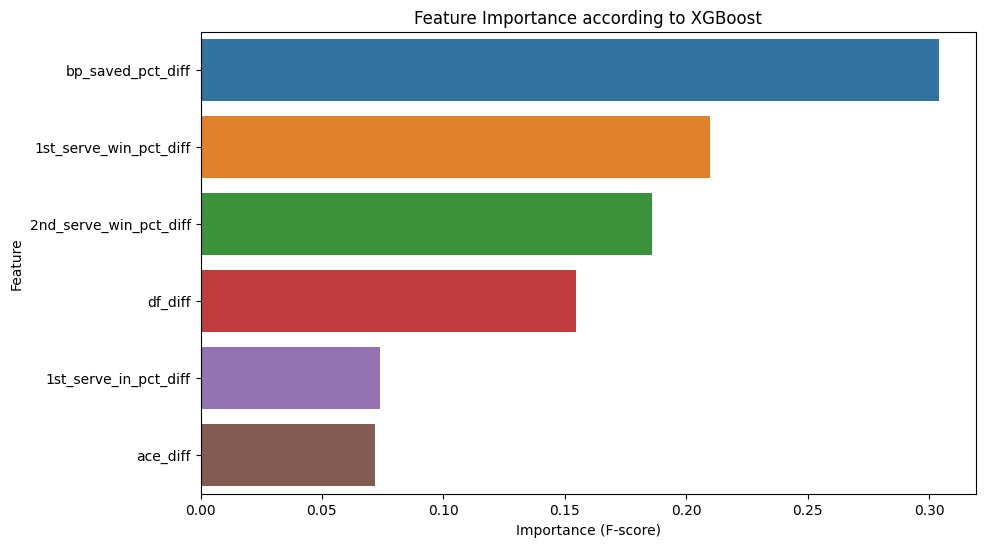

In [14]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Training the XGBoost Model ---
# Initialize the model with solid basic parameters.
# n_estimators: number of trees
# learning_rate (or eta): how much each tree contributes to the final prediction.
# random_state=42: for reproducibility.

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

print("Starting XGBoost training...")
# Train the model on the training data
xgb_model.fit(X_train, y_train)
print("Training completed.")


# --- 2. Making Predictions ---
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)


# --- 3. Model Evaluation ---
# Calculate performance metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n--- Model #4 Results (XGBoost) ---")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R-squared (R²): {r2_xgb:.4f}")


# --- 4. Interpretability Analysis (Feature Importance) ---

xgb_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance according to XGBoost ---")
print(xgb_importances)

# Visualizing feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importances)
plt.title('Feature Importance according to XGBoost')
plt.xlabel('Importance (F-score)')
plt.ylabel('Feature')
plt.show()


# Optimization of XGboost

In this section, we perform hyperparameter tuning on the XGBoost model using RandomizedSearchCV to improve its predictive performance. Unlike the previous fixed-parameter model, here we explore a range of values for key hyperparameters such as:

* n_estimators: the number of trees in the ensemble (from 100 to 500),
* learning_rate: how much each tree influences the final prediction (between 0.01 and 0.21),
* max_depth: the maximum depth of each tree (from 3 to 9),
* subsample: the fraction of samples used per tree (between 0.7 and 1.0),
* colsample_bytree: the fraction of features used per tree (between 0.7 and 1.0).

Randomized search efficiently samples this hyperparameter space, training multiple models to find the best combination that minimizes the root mean squared error (RMSE) on cross-validation sets. The tuned model is then evaluated on the test data, and feature importance is re-assessed to understand which variables most influence predictions.

Starting hyperparameter tuning...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Tuning completed.

Best hyperparameters found: {'colsample_bytree': 0.7808237001395564, 'learning_rate': 0.05882510444955484, 'max_depth': 5, 'n_estimators': 473, 'subsample': 0.765629265871921}

--- Results of the TUNED XGBoost Model ---
Mean Absolute Error (MAE): 2.0563
Root Mean Squared Error (RMSE): 2.6997
R-squared (R²): 0.1480

--- Feature Importance according to TUNED XGBoost ---
                  Feature  Importance
5       bp_saved_pct_diff    0.274604
3  1st_serve_win_pct_diff    0.208599
4  2nd_serve_win_pct_diff    0.166196
1                 df_diff    0.151413
2   1st_serve_in_pct_diff    0.100415
0                ace_diff    0.098774


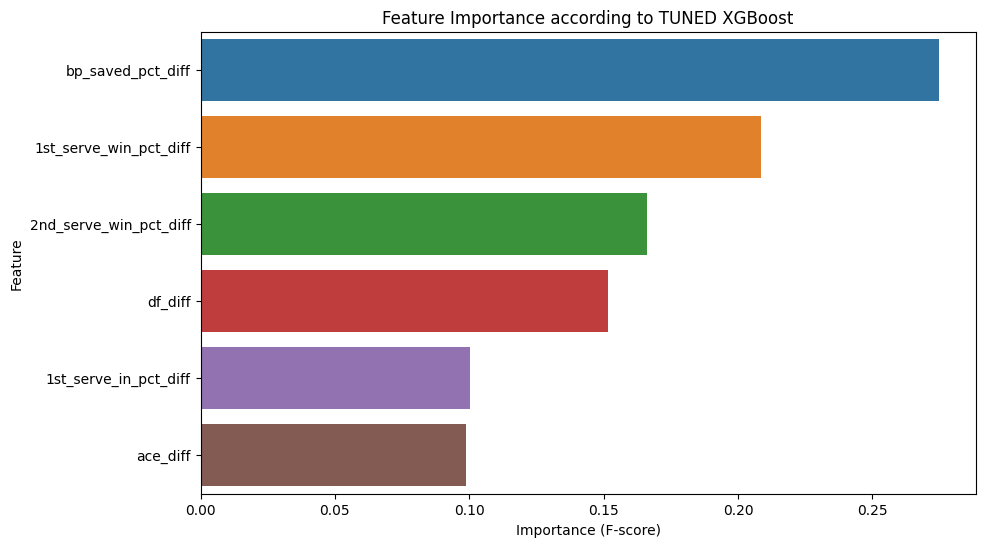

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the hyperparameter search space
param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.7, 0.3),  # Generates values between 0.7 and 1.0
    'colsample_bytree': uniform(0.7, 0.3)  # Generates values between 0.7 and 1.0
}

# Initialize the search
random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    verbose=1,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

print("Starting hyperparameter tuning...")
# Start tuning
random_search.fit(X_train, y_train)
print("Tuning completed.")

# Best model found
best_xgb_tuned = random_search.best_estimator_
print("\nBest hyperparameters found:", random_search.best_params_)

# --- Make Predictions using the TUNED MODEL ---
y_pred_xgb_tuned = best_xgb_tuned.predict(X_test)

# --- Evaluation of the TUNED MODEL ---
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("\n--- Results of the TUNED XGBoost Model ---")
print(f"Mean Absolute Error (MAE): {mae_xgb_tuned:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_tuned:.4f}")
print(f"R-squared (R²): {r2_xgb_tuned:.4f}")

# --- Interpretability Analysis of the TUNED MODEL ---
xgb_tuned_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb_tuned.feature_importances_  
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance according to TUNED XGBoost ---")
print(xgb_tuned_importances)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_tuned_importances)  
plt.title('Feature Importance according to TUNED XGBoost')
plt.xlabel('Importance (F-score)')
plt.ylabel('Feature')
plt.show()


# SHAP for the XGBoost


--- SHAP Analysis for the TUNED XGBoost Model (Service Only) ---
SHAP values calculation completed.

Generating SHAP Summary Plot...


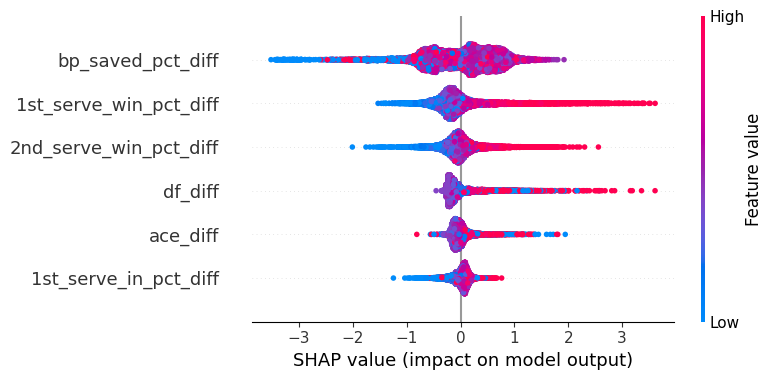

In [16]:
import shap
import matplotlib.pyplot as plt

print("\n--- SHAP Analysis for the TUNED XGBoost Model (Service Only) ---")

# --- 1. Create the Explainer and Compute SHAP Values ---
# We use TreeExplainer, optimized for tree-based models like XGBoost.
explainer = shap.TreeExplainer(best_xgb_tuned)

# Compute SHAP values for our test set.
shap_values = explainer.shap_values(X_test)

print("SHAP values calculation completed.")


# --- 2. Visualization with SHAP Summary Plot ---
print("\nGenerating SHAP Summary Plot...")

shap.summary_plot(shap_values, X_test, plot_type="dot")


##  Temporal analysis

In this section, we investigate whether the performance and behavior of the predictive model change over different historical periods. The dataset is split into two time segments: 2004–2013 and 2014–2023. For each period, a separate XGBoost model is trained using the same hyperparameters as the optimized global model. We then evaluate each model's accuracy using R² and MAE, and analyze feature importance with SHAP values. This allows us to identify shifts in feature relevance or prediction quality over time.

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2004-2013' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.


--- Starting Analysis for Segment: 2004-2013 ---
Number of matches: 26830
R-squared (R²): 0.1378
Mean Absolute Error (MAE): 2.0535
--------------------------------------------------

--- Starting Analysis for Segment: 2014-2023 ---
Number of matches: 25335
R-squared (R²): 0.1295
Mean Absolute Error (MAE): 2.1074
--------------------------------------------------

--- Comparative Performance Table by Time Period ---
   Period       R²      MAE
2004-2013 0.137762 2.053533
2014-2023 0.129459 2.107353
SHAP Summary Plot for period 2004-2013


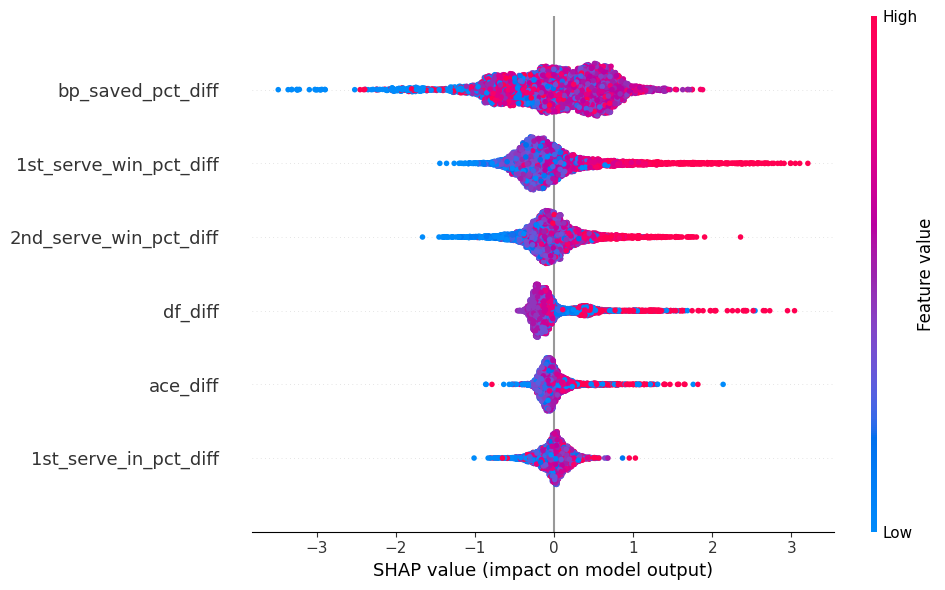

SHAP Summary Plot for period 2014-2023


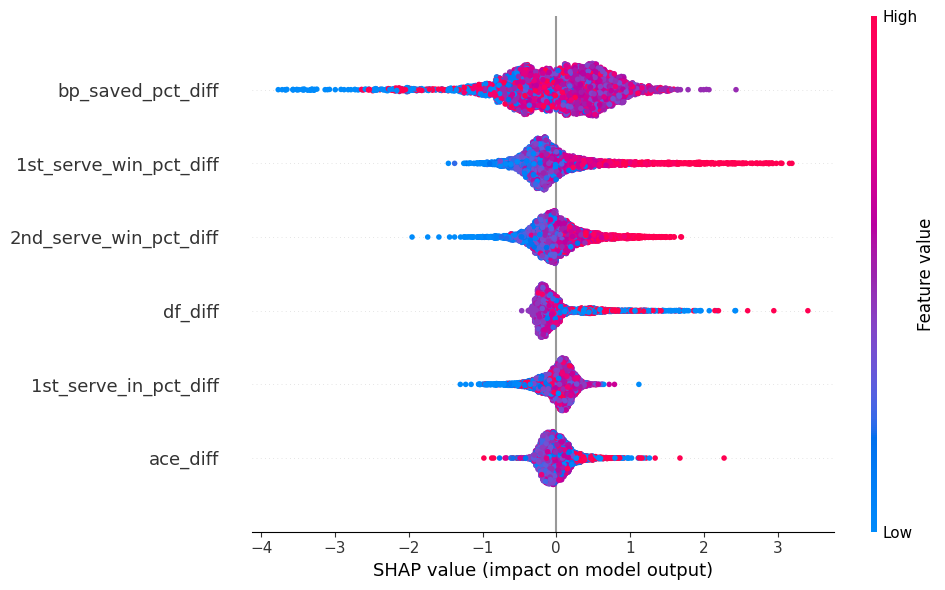

In [17]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import shap
import matplotlib.pyplot as plt

# --- Prerequisites ---
# 1. 'df_clean'
# 2. 'best_xgb_tuned'
# 3. The function 'analyze_surface' (assumed defined elsewhere)

# --- 1. Create Time Segment ---
df_clean['year'] = pd.to_datetime(df_clean['tourney_date'], format='%Y%m%d').dt.year

# Define periods
df_clean['period'] = np.nan  # Initialize the column
df_clean.loc[(df_clean['year'] >= 2004) & (df_clean['year'] < 2014), 'period'] = '2004-2013'
df_clean.loc[(df_clean['year'] >= 2014) & (df_clean['year'] < 2024), 'period'] = '2014-2023'

# Remove matches outside the periods of interest
df_temporal = df_clean.dropna(subset=['period']).copy()

# --- 2. Adapted Segment Analysis Function ---
def analyze_segment(segment_name, segment_col, df, model_template, feature_cols, target_col):
    """
    Generic workflow to analyze a data segment.
    """
    print(f"--- Starting Analysis for Segment: {segment_name.upper()} ---")
    
    df_segment = df[df[segment_col] == segment_name].copy()
    if len(df_segment) < 100:
        print(f"Insufficient data for segment {segment_name}. Skipping.")
        return None
        
    print(f"Number of matches: {len(df_segment)}")
    
    X = df_segment[feature_cols]
    y = df_segment[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = xgb.XGBRegressor(**model_template.get_params())
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    results = {'name': segment_name, 'r2': r2, 'mae': mae, 'shap_values': shap_values, 'X_test': X_test}
    
    print("-" * 50 + "\n")
    return results

# --- 3. Run Temporal Analysis ---
periods = ['2004-2013', '2014-2023']
temporal_results = {}

for period in periods:
    result = analyze_segment(period, 'period', df_temporal, best_xgb_tuned, feature_cols, target_col)
    if result:
        temporal_results[period] = result

# --- 4. Comparative Visualization of Results ---

# Performance comparison table
performance_data_temporal = []
for period, res in temporal_results.items():
    performance_data_temporal.append({'Period': period, 'R²': res['r2'], 'MAE': res['mae']})

df_performance_temporal = pd.DataFrame(performance_data_temporal)
print("--- Comparative Performance Table by Time Period ---")
print(df_performance_temporal.to_string(index=False))

# SHAP comparative plots
# --- 4. Visualization of SHAP plots by time period ---
for period in periods:
    if period in temporal_results:
        print(f"SHAP Summary Plot for period {period}")
        shap.summary_plot(
            temporal_results[period]['shap_values'],
            temporal_results[period]['X_test'],
            plot_size=(10, 6),
            show=True
        )


# Code for the Ranking Integration Experiment

To investigate whether the information captured by our service metrics was merely a reflection of player rankings, we conducted an additional experiment.
We trained a model using our six service-related features, adding only the ranking difference (log_rank_diff) as an extra feature.
The resulting model achieved an R² of 0.149 — a nearly negligible improvement over the baseline 'Service Only' model (R² = 0.148).
This crucial result demonstrates that in-match performance metrics are not redundant, and provide explanatory information that is distinct and independent from a player's historical reputation.



Final model features: ['ace_diff', 'df_diff', '1st_serve_in_pct_diff', '1st_serve_win_pct_diff', '2nd_serve_win_pct_diff', 'bp_saved_pct_diff', 'rank_diff']

Starting training of the final model...
Training completed.

--- Final Model Results (Service + Rank) ---
R-squared (R²): 0.1491
Mean Absolute Error (MAE): 2.0585

--- SHAP Summary Plot for the Final Model ---


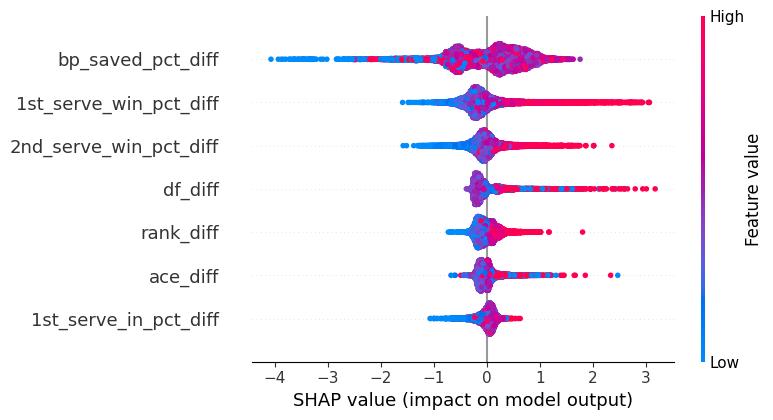

In [18]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import shap
import matplotlib.pyplot as plt

# --- Prerequisites ---
# 'df_clean': the DataFrame containing the original features and the columns 'winner_rank', 'loser_rank'.
# 'best_xgb_tuned': the optimized XGBoost model.
# 'feature_cols': the list of the 6 service-related features.

# --- 1. Data Preparation and New Feature Creation ---
df_final = df_clean.dropna(subset=['winner_rank', 'loser_rank'] + feature_cols).copy()

# Add the ranking difference
# A rank_diff > 0 means the winner had a worse ranking (an upset)
df_final['rank_diff'] = np.log(df_final['loser_rank']) - np.log(df_final['winner_rank'])

# Define the new set of features: the original 6 + the new one
final_feature_cols = feature_cols + ['rank_diff']
print("Final model features:", final_feature_cols)

X_final = df_final[final_feature_cols]
y_final = df_final[target_col]

# --- 2. Training and Evaluation of the Final Model ---
# Split the data
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Use our best tuned model
model_final = xgb.XGBRegressor(**best_xgb_tuned.get_params())
print("\nStarting training of the final model...")
model_final.fit(X_train_final, y_train_final)
print("Training completed.")

# Evaluation
y_pred_final = model_final.predict(X_test_final)
r2_final = r2_score(y_test_final, y_pred_final)
mae_final = mean_absolute_error(y_test_final, y_pred_final)

print(f"\n--- Final Model Results (Service + Rank) ---")
print(f"R-squared (R²): {r2_final:.4f}")
print(f"Mean Absolute Error (MAE): {mae_final:.4f}")

# --- 3. SHAP Analysis of the Final Model ---
# This is the most important interpretability analysis
explainer_final = shap.TreeExplainer(model_final)
shap_values_final = explainer_final.shap_values(X_test_final)

print("\n--- SHAP Summary Plot for the Final Model ---")
shap.summary_plot(shap_values_final, X_test_final)


# CLUSTER

--- 1. Data Preparation ---
Data standardized for clustering.

--- 2. Determining the Optimal Number of Clusters (Silhouette Score) ---
For k=2, the Silhouette Score is: 0.1538
For k=3, the Silhouette Score is: 0.1546
For k=4, the Silhouette Score is: 0.1476
For k=5, the Silhouette Score is: 0.1339
For k=6, the Silhouette Score is: 0.1314
For k=7, the Silhouette Score is: 0.1268
For k=8, the Silhouette Score is: 0.1198
For k=9, the Silhouette Score is: 0.1252
For k=10, the Silhouette Score is: 0.1251


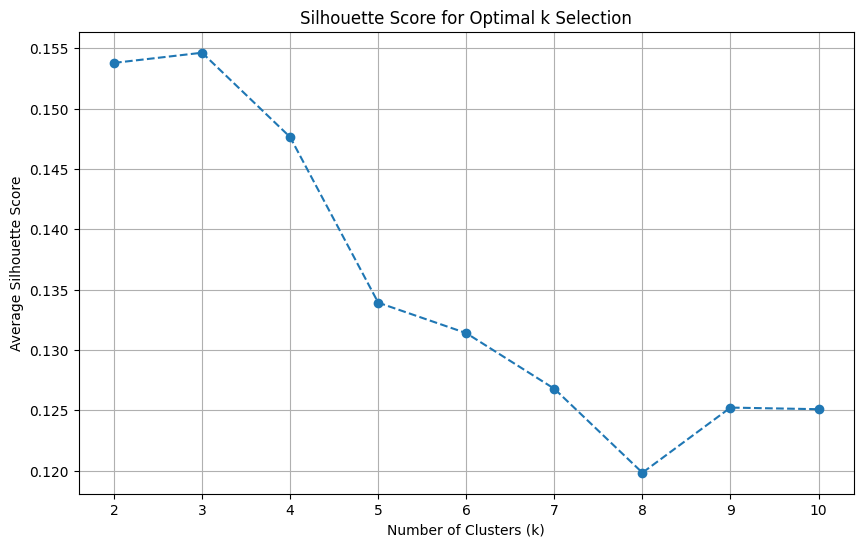


The optimal number of clusters is: k = 3

--- 3. Training and Interpreting the K-Means Model with k=3 ---
Cluster labels assigned.

Cluster Centroids (Average Feature Values per Profile):
   ace_diff   df_diff  1st_serve_in_pct_diff  1st_serve_win_pct_diff  \
0  2.894175  1.686935               0.015438                0.193686   
1  4.588991 -1.116905              -0.029874                0.133198   
2 -1.732559  2.115698               0.072463                0.028917   

   2nd_serve_win_pct_diff  bp_saved_pct_diff  cluster_id  num_matches  
0                0.219174          -0.306121           0        14024  
1                0.031164           0.220243           1        26889  
2                0.136943           0.178081           2        25401  

Profile names assigned.

--- 4. Analysis of Average Advantage (game_diff) by Profile ---
                        count      mean       std  min  25%  50%  75%   max
service_profile_name                                                

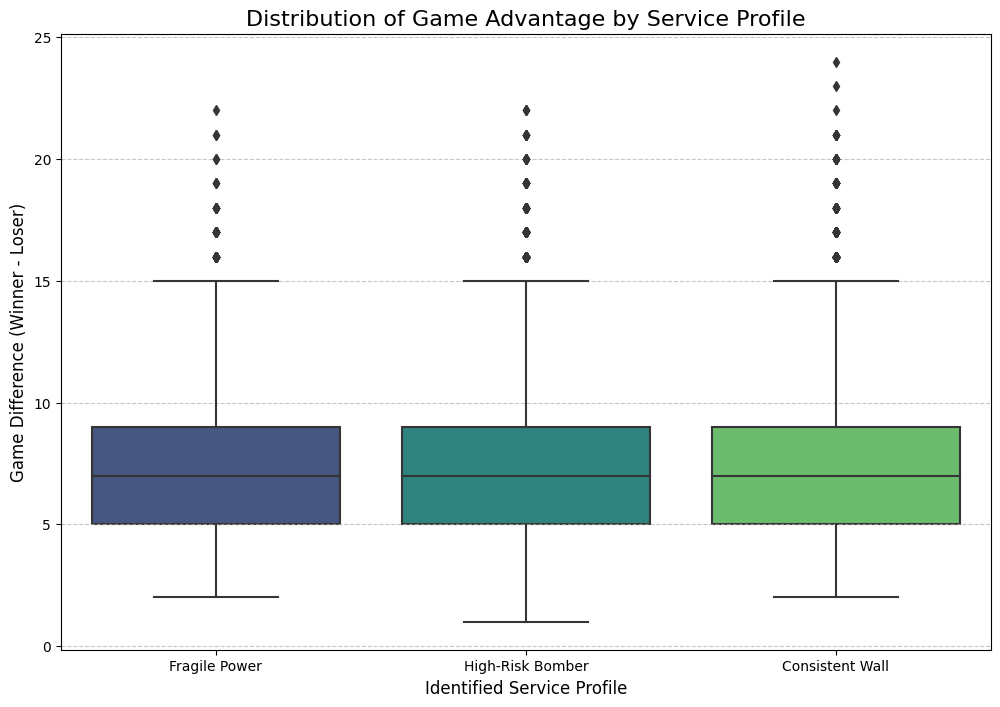


--- 5. (Optional) Profile Distribution for the Big 3 ---
service_profile_name  Consistent Wall  Fragile Power  High-Risk Bomber
winner_name                                                           
Novak Djokovic               0.410546       0.295669          0.293785
Rafael Nadal                 0.533398       0.282672          0.183930
Roger Federer                0.280792       0.341085          0.378122


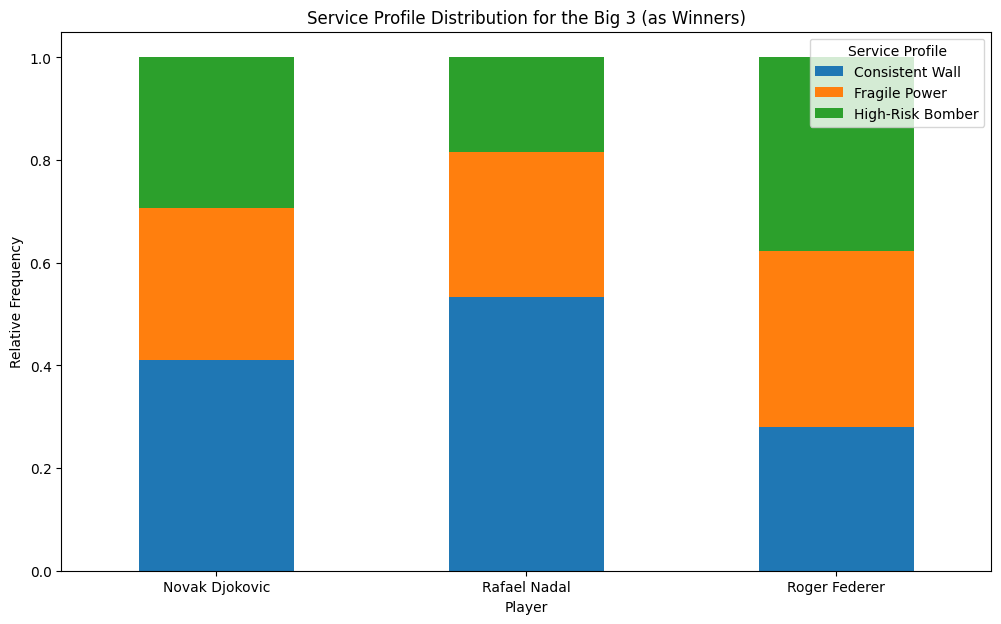

In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Preparation for Clustering ---
print("--- 1. Data Preparation ---")
# 'df_clean' is the DataFrame containing the 6 original 'feature_cols'.
# 'feature_cols' is the list of 6 service features.
df_cluster_data = df_clean[feature_cols].copy()

# Standardize the data: K-Means is distance-based.
scaler_cluster = StandardScaler()
features_scaled_cluster = scaler_cluster.fit_transform(df_cluster_data)
print("Data standardized for clustering.")


# --- 2. Choosing the Optimal Number of Clusters using Silhouette Score ---
print("\n--- 2. Determining the Optimal Number of Clusters (Silhouette Score) ---")
silhouette_scores = []
k_range = range(2, 11)  # Start from 2 for silhouette score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels_temp = kmeans.fit_predict(features_scaled_cluster)
    score = silhouette_score(features_scaled_cluster, cluster_labels_temp)
    silhouette_scores.append(score)
    print(f"For k={k}, the Silhouette Score is: {score:.4f}")

# Plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Score for Optimal k Selection')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Choose the k that maximized the silhouette score
OPTIMAL_K = k_range[np.argmax(silhouette_scores)]
print(f"\nThe optimal number of clusters is: k = {OPTIMAL_K}")


# --- 3. Training Final K-Means Model and Interpretation ---
print(f"\n--- 3. Training and Interpreting the K-Means Model with k={OPTIMAL_K} ---")
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(features_scaled_cluster)

# Add numeric cluster labels to the original DataFrame
df_clean['service_profile_id'] = cluster_labels
print("Cluster labels assigned.")

# Analyze cluster centroids
centroids_scaled = kmeans_final.cluster_centers_
centroids = scaler_cluster.inverse_transform(centroids_scaled)
df_centroids = pd.DataFrame(centroids, columns=feature_cols)
df_centroids['cluster_id'] = df_centroids.index
cluster_sizes = df_clean['service_profile_id'].value_counts().sort_index()
df_centroids['num_matches'] = cluster_sizes
print("\nCluster Centroids (Average Feature Values per Profile):")
print(df_centroids)

# Map profile names (based on your k=3 result)
profile_map = {
    0: 'Fragile Power',
    1: 'High-Risk Bomber',
    2: 'Consistent Wall'
}
df_clean['service_profile_name'] = df_clean['service_profile_id'].map(profile_map)
print("\nProfile names assigned.")


# --- 4. Analyzing the Impact of Profiles on Match Outcome ---
print("\n--- 4. Analysis of Average Advantage (game_diff) by Profile ---")
profile_impact_summary = df_clean.groupby('service_profile_name')['game_diff'].describe()
print(profile_impact_summary)

# Boxplot visualization
order = profile_impact_summary['mean'].sort_values(ascending=False).index
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_clean,
    x='service_profile_name',
    y='game_diff',
    order=order,
    palette='viridis'
)
plt.title('Distribution of Game Advantage by Service Profile', fontsize=16)
plt.xlabel('Identified Service Profile', fontsize=12)
plt.ylabel('Game Difference (Winner - Loser)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# --- 5. (Optional) Profile Distribution of the Big 3 ---
print("\n--- 5. (Optional) Profile Distribution for the Big 3 ---")
big_3_profiles = df_clean[df_clean['winner_name'].isin(['Roger Federer', 'Rafael Nadal', 'Novak Djokovic'])]
if not big_3_profiles.empty:
    profile_distribution = big_3_profiles.groupby('winner_name')['service_profile_name'].value_counts(normalize=True).unstack(fill_value=0)
    print(profile_distribution)
    profile_distribution.plot(kind='bar', stacked=True, figsize=(12, 7),
                              title='Service Profile Distribution for the Big 3 (as Winners)')
    plt.ylabel('Relative Frequency')
    plt.xlabel('Player')
    plt.xticks(rotation=0)
    plt.legend(title='Service Profile')
    plt.show()
else:
    print("No data available for the Big 3 in the analyzed sample.")


# Impatto dei diversi tipi di profili individuati


--- Analysis of Average Game Advantage (game_diff) by Service Profile ---
Descriptive statistics of game_diff for each profile:
                        count      mean       std  min  25%  50%  75%   max
service_profile_name                                                       
Consistent Wall       25401.0  7.045786  2.960247  2.0  5.0  7.0  9.0  24.0
Fragile Power         14024.0  7.249287  2.711502  2.0  5.0  7.0  9.0  22.0
High-Risk Bomber      26889.0  7.083938  2.961367  1.0  5.0  7.0  9.0  22.0


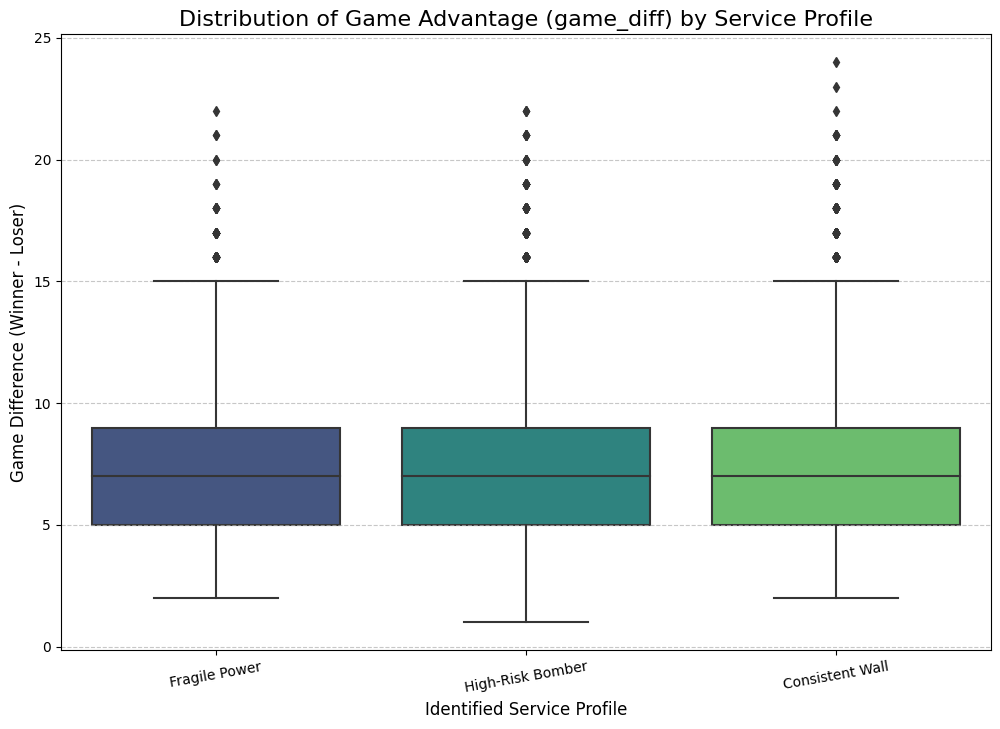

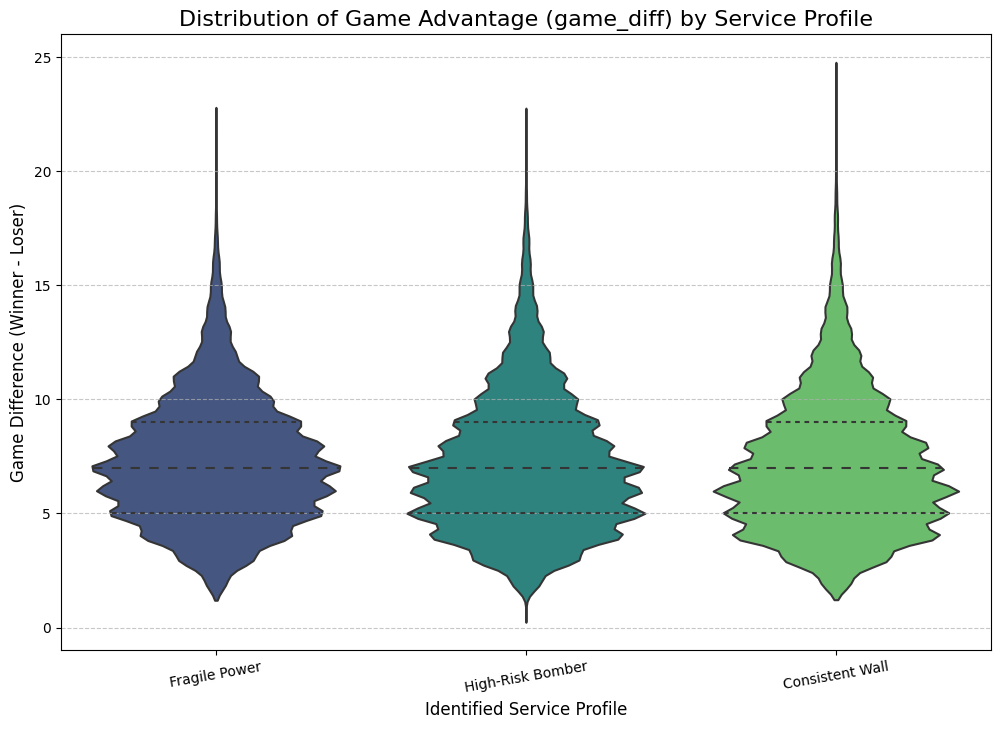

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prerequisite ---
# 'df_clean' must contain both the 'game_diff' and 'service_profile_name' columns.
# The 'profile_map' should already be defined and applied.

print("\n--- Analysis of Average Game Advantage (game_diff) by Service Profile ---")

# Group by profile and compute descriptive statistics for game_diff
profile_impact_summary = df_clean.groupby('service_profile_name')['game_diff'].describe()

print("Descriptive statistics of game_diff for each profile:")
print(profile_impact_summary)


# --- Visualization with Box Plot ---
# The box plot is ideal for comparing distributions.

# Sort profiles by average game_diff for clearer visualization
order = profile_impact_summary['mean'].sort_values(ascending=False).index

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_clean,
    x='service_profile_name',
    y='game_diff',
    order=order,  # Apply the sorted order
    palette='viridis'
)

plt.title('Distribution of Game Advantage (game_diff) by Service Profile', fontsize=16)
plt.xlabel('Identified Service Profile', fontsize=12)
plt.ylabel('Game Difference (Winner - Loser)', fontsize=12)
plt.xticks(rotation=10)  # Slight rotation for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# --- Alternative Visualization with Violin Plot ---
# The violin plot also shows the density of the distribution.
plt.figure(figsize=(12, 8))
sns.violinplot(
    data=df_clean,
    x='service_profile_name',
    y='game_diff',
    order=order,
    palette='viridis',
    inner='quartile'  # Show quartiles inside the violins
)
plt.title('Distribution of Game Advantage (game_diff) by Service Profile', fontsize=16)
plt.xlabel('Identified Service Profile', fontsize=12)
plt.ylabel('Game Difference (Winner - Loser)', fontsize=12)
plt.xticks(rotation=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# STUDY ON PREDICTION USING NON-SERVICE FEATURES

--- FINAL CONTROL EXPERIMENT (FEATURES v3 - ENRICHED) ---
Feature engineering completed for the 'Other Stats' model.

--- Training Model 'Only Other Stats' ---


invalid value encountered in log
invalid value encountered in greater


R-squared (R²): 0.3401
Mean Absolute Error (MAE): 1.7988

--- Final Comparison of Explanatory Power ---
      Feature Group  R-squared (R²)      MAE
    1. Only Service        0.148000 2.056300
2. Only Other Stats        0.340132 1.798841

--- SHAP Analysis for the 'Only Other Stats' Model ---


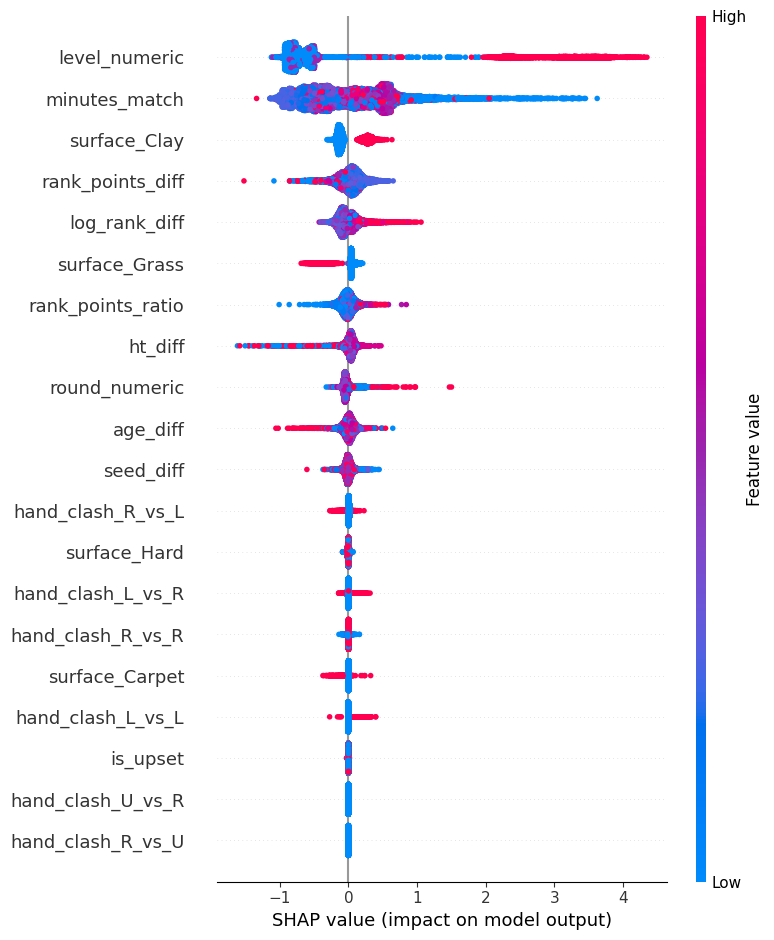

In [21]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
import shap

# --- Prerequisites ---
# 'df_clean': the DataFrame with all required columns.
# 'best_xgb_tuned': the optimized XGBoost model.
# 'feature_cols': the list of the 6 service features.
# 'target_col': the string 'game_diff'.

print("--- FINAL CONTROL EXPERIMENT (FEATURES v3 - ENRICHED) ---")

# --- 1. Preparation of "Other Features" ---
df_final_exp = df_clean.copy()

# A. Create numerical features
df_final_exp['rank_points_diff'] = df_final_exp['winner_rank_points'] - df_final_exp['loser_rank_points']
df_final_exp['log_rank_diff'] = np.log(df_final_exp['loser_rank']) - np.log(df_final_exp['winner_rank'])
df_final_exp['age_diff'] = df_final_exp['winner_age'] - df_final_exp['loser_age']
df_final_exp['ht_diff'] = df_final_exp['winner_ht'] - df_final_exp['loser_ht']
df_final_exp['minutes_match'] = df_final_exp['minutes']

# Seed handling
df_final_exp['w_seed_filled'] = df_final_exp['winner_seed'].fillna(33)
df_final_exp['l_seed_filled'] = df_final_exp['loser_seed'].fillna(33)
df_final_exp['seed_diff'] = df_final_exp['l_seed_filled'] - df_final_exp['w_seed_filled']

# B. Ordinal feature handling
round_map = {'R128': 1, 'R64': 2, 'R32': 3, 'R16': 4, 'QF': 5, 'RR': 5, 'SF': 6, 'F': 7}
df_final_exp['round_numeric'] = df_final_exp['round'].map(round_map)

level_map = {'D': 1, 'C': 1, 'A': 2, 'M': 3, 'G': 4, 'F': 5}
df_final_exp['level_numeric'] = df_final_exp['tourney_level'].map(level_map)

# C. Categorical feature handling and new binary/ratio features
df_final_exp['hand_clash'] = df_final_exp['winner_hand'] + '_vs_' + df_final_exp['loser_hand']

# New additional features
df_final_exp['is_upset'] = (df_final_exp['winner_rank'] > df_final_exp['loser_rank']).astype(int)
df_final_exp['rank_points_ratio'] = (df_final_exp['winner_rank_points'] + 1) / (df_final_exp['loser_rank_points'] + 1)

# Final list of features to be used
other_numeric_features_v3 = [
    'rank_points_diff', 'log_rank_diff', 'age_diff', 'ht_diff', 
    'minutes_match', 'seed_diff', 'round_numeric', 'level_numeric',
    'rank_points_ratio', 'is_upset'
]
other_categorical_features_v3 = ['surface', 'hand_clash']

# Remove rows with missing values in selected columns
cols_to_check_v3 = other_numeric_features_v3 + other_categorical_features_v3
df_final_exp.dropna(subset=cols_to_check_v3, inplace=True)

# D. One-Hot Encoding
encoder_v3 = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_cats_v3 = encoder_v3.fit_transform(df_final_exp[other_categorical_features_v3])
encoded_cols_v3 = encoder_v3.get_feature_names_out(other_categorical_features_v3)
df_encoded_v3 = pd.DataFrame(encoded_cats_v3, index=df_final_exp.index, columns=encoded_cols_v3)

# Combine everything into the final feature set
X_other_v3 = pd.concat([df_final_exp[other_numeric_features_v3], df_encoded_v3], axis=1)
y_other_v3 = df_final_exp[target_col]
print("Feature engineering completed for the 'Other Stats' model.")

# --- 2. Training and Evaluation of the 'Other Features v3' Model ---
print("\n--- Training Model 'Only Other Stats' ---")
X_train_o3, X_test_o3, y_train_o3, y_test_o3 = train_test_split(X_other_v3, y_other_v3, test_size=0.2, random_state=42)

model_o3 = xgb.XGBRegressor(**best_xgb_tuned.get_params())
model_o3.fit(X_train_o3, y_train_o3)

y_pred_o3 = model_o3.predict(X_test_o3)
r2_o3 = r2_score(y_test_o3, y_pred_o3)
mae_o3 = mean_absolute_error(y_test_o3, y_pred_o3)

print(f"R-squared (R²): {r2_o3:.4f}")
print(f"Mean Absolute Error (MAE): {mae_o3:.4f}\n")

# --- 3. Final Comparison ---
print("--- Final Comparison of Explanatory Power ---")

results_final_comp_v3 = pd.DataFrame({
    'Feature Group': ['1. Only Service', '2. Only Other Stats'],
    'R-squared (R²)': [0.1480, r2_o3],
    'MAE': [2.0563, mae_o3]
})
print(results_final_comp_v3.to_string(index=False))

# --- 4. SHAP Analysis of the 'Other Features' Model ---
print("\n--- SHAP Analysis for the 'Only Other Stats' Model ---")
explainer_o3 = shap.TreeExplainer(model_o3)
shap_values_o3 = explainer_o3.shap_values(X_test_o3)
shap.summary_plot(shap_values_o3, X_test_o3)


--- 1. Creating Dataset for the Combined Model (Service + Other) ---
Final combined feature set shape: (63689, 26)

--- 2. Training Combined Model ---
Training completed.
R-squared (R²): 0.4136
Mean Absolute Error (MAE): 1.6372

--- 3. Final Comparison of Explanatory Power ---
              Model  R-squared (R²)      MAE
    1. Service Only        0.148000 2.056300
2. Only Other Stats        0.340132 1.798841
  3. Final Combined        0.413593 1.637236

--- 4. SHAP Analysis for the Final Combined Model ---


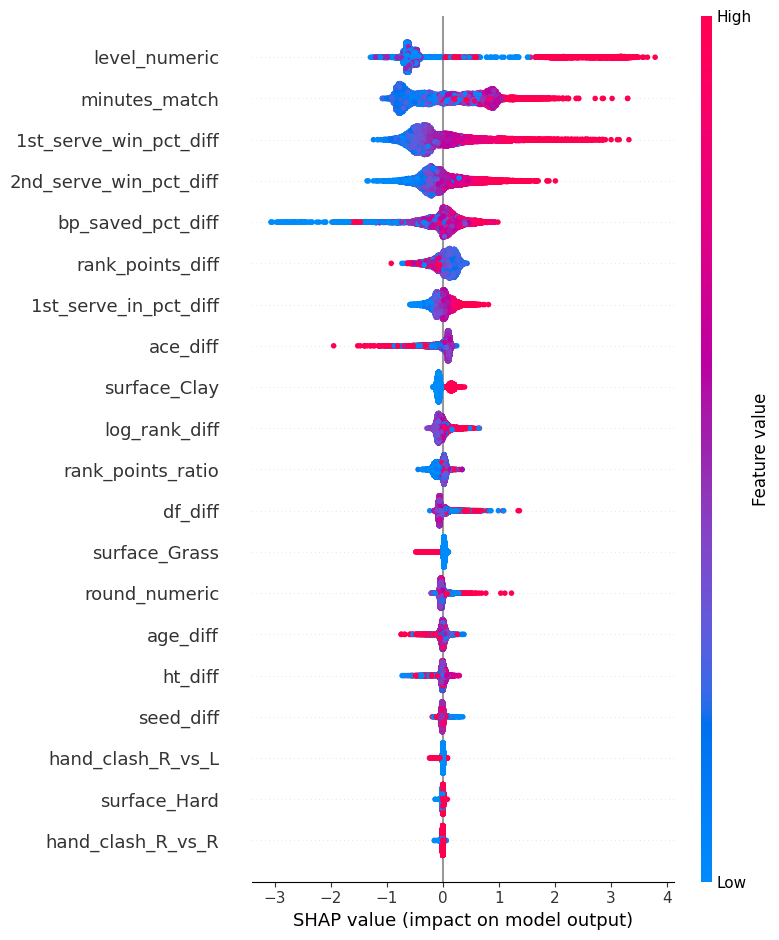

In [22]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import shap

# --- 1. Creation of the Combined Dataset ---
print("\n--- 1. Creating Dataset for the Combined Model (Service + Other) ---")

# We combine the 6 service features with the DataFrame we just created.
X_combined_v3 = pd.concat([df_final_exp.loc[X_other_v3.index, feature_cols], X_other_v3], axis=1)
y_combined_v3 = df_final_exp.loc[X_other_v3.index, target_col]

print("Final combined feature set shape:", X_combined_v3.shape)

# --- 2. Training and Evaluation of the Final Combined Model ---
print("\n--- 2. Training Combined Model ---")
X_train_cb3, X_test_cb3, y_train_cb3, y_test_cb3 = train_test_split(X_combined_v3, y_combined_v3, test_size=0.2, random_state=42)

# Initialize the model using the best hyperparameters
model_combined_v3 = xgb.XGBRegressor(**best_xgb_tuned.get_params())
model_combined_v3.fit(X_train_cb3, y_train_cb3)
print("Training completed.")

# Evaluate the combined model
y_pred_cb3 = model_combined_v3.predict(X_test_cb3)
r2_cb3 = r2_score(y_test_cb3, y_pred_cb3)
mae_cb3 = mean_absolute_error(y_test_cb3, y_pred_cb3)

print(f"R-squared (R²): {r2_cb3:.4f}")
print(f"Mean Absolute Error (MAE): {mae_cb3:.4f}\n")

# --- 3. Final Comparison Table ---
print("--- 3. Final Comparison of Explanatory Power ---")

# Store the results of the "Service Only" model
r2_service_only = 0.1480 
mae_service_only = 2.0563

# Create the final table using the results from all 3 models
results_definitive_v3 = pd.DataFrame({
    'Model': ['1. Service Only', '2. Only Other Stats', '3. Final Combined'],
    'R-squared (R²)': [r2_service_only, r2_o3, r2_cb3],
    'MAE': [mae_service_only, mae_o3, mae_cb3]        
})
print(results_definitive_v3.to_string(index=False))

# --- 4. SHAP Analysis of the Final Model ---
print("\n--- 4. SHAP Analysis for the Final Combined Model ---")
explainer_cb3 = shap.TreeExplainer(model_combined_v3)
shap_values_cb3 = explainer_cb3.shap_values(X_test_cb3)

shap.summary_plot(shap_values_cb3, X_test_cb3)
